#### To perform Polynomial Linear Regression using Hyper Parameter Tuning


##### Step 1:   Import  all the necessary libraries

In [621]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection  import  train_test_split, GridSearchCV, KFold
from    sklearn.preprocessing    import  StandardScaler,   PolynomialFeatures
from    sklearn.linear_model     import  LinearRegression
from    sklearn.pipeline         import  Pipeline
from    sklearn.metrics          import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2: Load the dataset

In [622]:
df = pd.read_csv("height-weight.csv")

In [623]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


#### OBSERVATIONS:

1.  The above dataset explains the Weight vs Height for different persons in the data.

#### Step 3: Perform the Data Exploration

In [624]:
#### get the top five rows of the dataset

df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [625]:
#### get the bottom  five rows of the dataset

df.tail()

,Weight,Height
18,76,150
19,87,167
20,45,129
21,56,140
22,72,160


In [626]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 23


In [627]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (23, 2)


In [628]:
#### get the columns used in the dataset

df.columns

Index(['Weight', 'Height'], dtype='object')

In [629]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 496.0 bytes


#### OBSERVATIONS:

1.  The Weight and the Height are the two columns having integer type in the dataset.

In [630]:
#### get the descriptive summary statistics about the data

df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


#### OBSERVATIONS:

1.  The above statistics explains about the statistical summary for each column in the dataset.

In [631]:
#### get the correlation between the numerical columns in the dataset

df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


<Axes: >

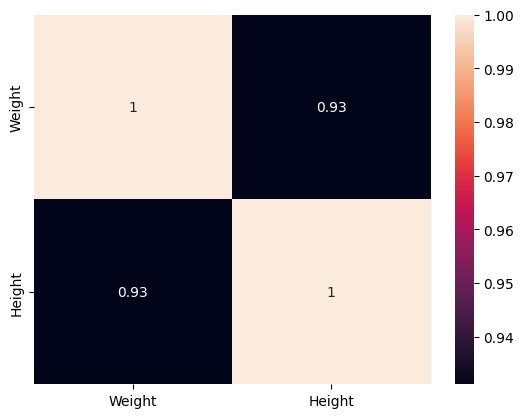

In [632]:
#### get the graphical representation for the correlation between the numerical columns in the dataset

sns.heatmap(df.corr(), annot=True)

#### OBSERVATIONS:

1.  The above  graph depicts that there is a high correlation between all the numrical columns in the dataset.

#### Step 4: Perform the Data Cleaning

In [633]:
#### To check for the NULL Values in the dataset

df.isnull().sum()

Weight    0
Height    0
dtype: int64

#### OBBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [634]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,Weight,Height
11,95,182


#### OBSERVATIONS:

1.  There is only one duplicate record in the dataset. So remove it.

In [635]:
df = df.drop_duplicates()

In [636]:
#### To again check for the duplicate records in the dataset

df[df.duplicated()]

,Weight,Height


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Divide the dataset into independent and dependent features

In [637]:
#### independent features

X = df.drop(columns='Height',axis=1)

print(X)

    Weight
0       45
1       58
2       48
3       60
4       70
5       78
6       80
7       90
8       95
9       78
10      82
12     105
13     100
14      85
15      78
16      50
17      65
18      76
19      87
20      45
21      56
22      72


In [638]:
#### dependent features

Y = df[['Height']]
print(Y)

    Height
0      120
1      135
2      123
3      145
4      160
5      162
6      163
7      175
8      182
9      170
10     176
12     175
13     183
14     170
15     177
16     140
17     159
18     150
19     167
20     129
21     140
22     160


#### Step 6: Divide the indpendent and dependent features into training and testing data

In [639]:
from  sklearn.model_selection import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state = 42)

In [640]:
X_train

,Weight
5,78
21,56
12,105
3,60
4,70
18,76
13,100
19,87
17,65
2,48


In [641]:
X_test

,Weight
0,45
14,85
8,95
1,58
16,50


In [642]:
print("Shape of the input training data is:",X_train.shape)
print("Shape of the input testing  data is:",X_test.shape)

Shape of the input training data is: (17, 1)
Shape of the input testing  data is: (5, 1)


In [643]:
Y_train

,Height
5,162
21,140
12,175
3,145
4,160
18,150
13,183
19,167
17,159
2,123


In [644]:
Y_test

,Height
0,120
14,170
8,182
1,135
16,140


In [645]:
print("Shape of the output training data is:",Y_train.shape)
print("Shape of the output testing  data is:",Y_test.shape)

Shape of the output training data is: (17, 1)
Shape of the output testing  data is: (5, 1)


#### Step 7: Perform Hyper Parameter Tuning using GridSearchCV

In [646]:
#### define the pipeline

from  sklearn.pipeline      import  Pipeline
from  sklearn.linear_model  import  Ridge


#### create an object for pipeline

pipeline = Pipeline([
    ("poly"     ,   PolynomialFeatures(degree=4))                ,
    ("sc"       ,   StandardScaler())                            ,
    ("ridge"    ,   Ridge(alpha=0.1))
])

In [647]:
#### create the parameter list

param_list = {
    "poly__degree"   :   [1,  2,  3,  4]                       ,
    "ridge__alpha"   :   [0.01, 0.1, 1,  10, 100]
}

In [648]:
#### create the KFold cross validation

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [649]:
#### Create the object for grid search cv

grid = GridSearchCV(
    pipeline                                                    ,
    param_grid         =             param_list                 ,
    cv                 =             cv                         ,
    scoring            =             'r2' 
)

In [650]:
#### Train the grid serach cv model

grid.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('poly', PolynomialFeatures(degree=4)),
                                       ('sc', StandardScaler()),
                                       ('ridge', Ridge(alpha=0.1))]),
             param_grid={'poly__degree': [1, 2, 3, 4],
                         'ridge__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [651]:
#### Find out the best parameters and estimators from the GridSearchCV Model

best_parameters = grid.best_params_

print("Best Parameters of the model is:", best_parameters)

Best Parameters of the model is: {'poly__degree': 2, 'ridge__alpha': 0.01}


In [652]:
best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Estimator of the model is: Pipeline(steps=[('poly', PolynomialFeatures()), ('sc', StandardScaler()),
                ('ridge', Ridge(alpha=0.01))])


In [653]:
#### Predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [654]:
Y_pred_grid

array([[124.49954123],
       [170.98457166],
       [176.38694629],
       [143.97283197],
       [132.48677907]])

In [655]:
#### Find out the accuracy of the model

from  sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_pred_grid)

print("R2 Score of the model is:", r2)

R2 Score of the model is: 0.9283462425323632


#### OBSERVATIONS:

1.  The R2 Score of the model is 0.9283 which is very high. So the model is working fine.